# Data analysis for talk March 2021, should be elsewhere 

Exp 1p1
Using a single icosahedral net

In [1]:
# lets load our libraries
#!conda install -y -c conda-forge numpy=1.19.5
import deepchem as dc
from rdkit import Chem
from rdkit.Chem import Draw
import tensorflow as tf
import os
import sys
import rdkit
import h5py

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri 
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("DeepChem version: " + dc.__version__)
print("TensorFlow version: " + tf.__version__)

# topology stuff 
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face
import csv

C:\Users\ella_\.conda\envs\ml-for-chemists-tf1\lib\site-packages\sklearn\externals\joblib\__init__.py:15: FutureWarning: sklearn.externals.joblib is deprecated in 0.21 and will be removed in 0.23. Please import this functionality directly from joblib, which can be installed with: pip install joblib. If this warning is raised when loading pickled models, you may need to re-serialize those models with scikit-learn 0.21+.
  warnings.warn(msg, category=FutureWarning)
C:\Users\ella_\.conda\envs\ml-for-chemists-tf1\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\ella_\.conda\envs\ml-for-chemists-tf1\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of num

DeepChem version: 2.3.0
TensorFlow version: 1.14.0


In [2]:
data=pd.read_csv("CombinedMore.csv")
data.head()

,name,dataset,tr_mse,tr_r2,tr_mae,tr_rmse,dataset2,val_mse,val_r2,val_mae,...,te_mse,te_r2,te_mae,te_rmse,name.1,dataset.1,gen_mse,gen_r2,gen_mae,gen_rmse
0,2021_PDBBind_core_augmented_div4_normalised.hd...,Train,0.207333,0.958071,0.370695,0.456917,Validation,2.409569,0.449690,1.253675,...,5.002298,0.181916,1.712738,2.234921,2021_PDBBind_core_augmented_div4_normalised.hd...,Generalisation,3.780577,0.047348,1.568368,1.944371
1,2021_PDBBind_core_augmented_div4_normalised.hd...,Train,0.008926,0.998024,0.085776,0.092570,Validation,5.161996,-0.003257,1.922805,...,5.363487,-0.145604,1.894344,2.316513,2021_PDBBind_core_augmented_div4_normalised.hd...,Generalisation,4.400738,-0.108883,1.691212,2.097792
2,2021_PDBBind_core_augmented_div4_normalised.hd...,Train,0.216933,0.957320,0.375746,0.466374,Validation,2.647529,0.192033,1.245297,...,5.425860,0.122039,2.034541,2.340929,2021_PDBBind_core_augmented_div4_normalised.hd...,Generalisation,4.528799,-0.141197,1.722135,2.128102
3,2021_PDBBind_core_augmented_div4_normalised.hd...,Train,0.152379,0.967833,0.321555,0.391411,Validation,4.733170,0.331332,1.738059,...,4.072640,0.302258,1.610296,2.020415,2021_PDBBind_core_augmented_div4_normalised.hd...,Generalisation,3.795760,0.043476,1.566001,1.948195
4,2021_PDBBind_core_augmented_div4_normalised.hd...,Train,0.021142,0.996076,0.130247,0.146546,Validation,3.580909,0.090207,1.466797,...,4.511969,0.071491,1.752148,2.138135,2021_PDBBind_core_augmented_div4_normalised.hd...,Generalisation,4.627087,-0.166088,1.734386,2.151077


In [3]:
print(data["name"][0])
val_scores_1p1_rmse=[data["val_rmse"][0:5]]
test_scores_1p1_rmse=[data["te_rmse"][0:5]]
gen_scores_1p1_rmse=[data["gen_rmse"][0:5]]

print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores=gen_scores_1p1_rmse, 
                                  test_scores=test_scores_1p1_rmse, 
                                  validate_scores=val_scores_1p1_rmse)
(min_gen_1p1_rmse, 
     mean_gen_1p1_rmse, 
     std_error_gen_1p1_rmse, 
     max_gen_1p1_rmse,
     min_val_1p1_rmse, 
     mean_val_1p1_rmse, 
     std_error_val_1p1_rmse, 
     max_val_1p1_rmse,
     min_test_1p1_rmse, 
     mean_test_1p1_rmse, 
     std_error_test_1p1_rmse, 
     max_test_1p1_rmse
     )=out_rmse




2021_PDBBind_core_augmented_div4_normalised.hdf5_-logKd_over_Ki_2021_03_09_NEW_YAED4head_Core_Exp1_1_1_177

		RMSE results
training: 	 1.94 <	 2.05. +/- 0.0895 	< 2.15 
validation: 	 1.55 <	 1.89. +/- 0.285 	< 2.24 
testing: 	 2.02 <	 2.21. +/- 0.119 	< 2.34 


In [4]:
print(data["name"][6])
val_scores_1p2_rmse=[data["val_rmse"][5:10]]
test_scores_1p2_rmse=[data["te_rmse"][5:10]]
gen_scores_1p2_rmse=[data["gen_rmse"][5:10]]

print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores=gen_scores_1p2_rmse, 
                                  test_scores=test_scores_1p2_rmse, 
                                  validate_scores=val_scores_1p2_rmse)
(min_gen_1p2_rmse, 
     mean_gen_1p2_rmse, 
     std_error_gen_1p2_rmse, 
     max_gen_1p2_rmse,
     min_val_1p2_rmse, 
     mean_val_1p2_rmse, 
     std_error_val_1p2_rmse, 
     max_val_1p2_rmse,
     min_test_1p2_rmse, 
     mean_test_1p2_rmse, 
     std_error_test_1p2_rmse, 
     max_test_1p2_rmse
     )=out_rmse




2021_PDBBind_core_augmented_div4_normalised.hdf5_-logKd_over_Ki_2021_03_09_NEW_YAED4head_Core_Exp1_2_2_108

		RMSE results
training: 	 1.88 <	 1.9. +/- 0.0209 	< 1.94 
validation: 	 1.73 <	 2.02. +/- 0.223 	< 2.4 
testing: 	 1.69 <	 1.98. +/- 0.167 	< 2.13 


In [5]:
print(data["name"][10])
val_scores_1p3_rmse=[data["val_rmse"][10:15]]
test_scores_1p3_rmse=[data["te_rmse"][10:15]]
gen_scores_1p3_rmse=[data["gen_rmse"][10:15]]

print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores=gen_scores_1p3_rmse, 
                                  test_scores=test_scores_1p3_rmse, 
                                  validate_scores=val_scores_1p3_rmse)
(min_gen_1p3_rmse, 
     mean_gen_1p3_rmse, 
     std_error_gen_1p3_rmse, 
     max_gen_1p3_rmse,
     min_val_1p3_rmse, 
     mean_val_1p3_rmse, 
     std_error_val_1p3_rmse, 
     max_val_1p3_rmse,
     min_test_1p3_rmse, 
     mean_test_1p3_rmse, 
     std_error_test_1p3_rmse, 
     max_test_1p3_rmse
     )=out_rmse




2021_PDBBind_core_augmented_div4_normalised.hdf5_-logKd_over_Ki_2021_03_09_NEW_YAED4head_Core_Exp1_3_1_178

		RMSE results
training: 	 1.93 <	 1.98. +/- 0.0419 	< 2.05 
validation: 	 1.69 <	 1.94. +/- 0.183 	< 2.14 
testing: 	 1.85 <	 2.07. +/- 0.2 	< 2.37 


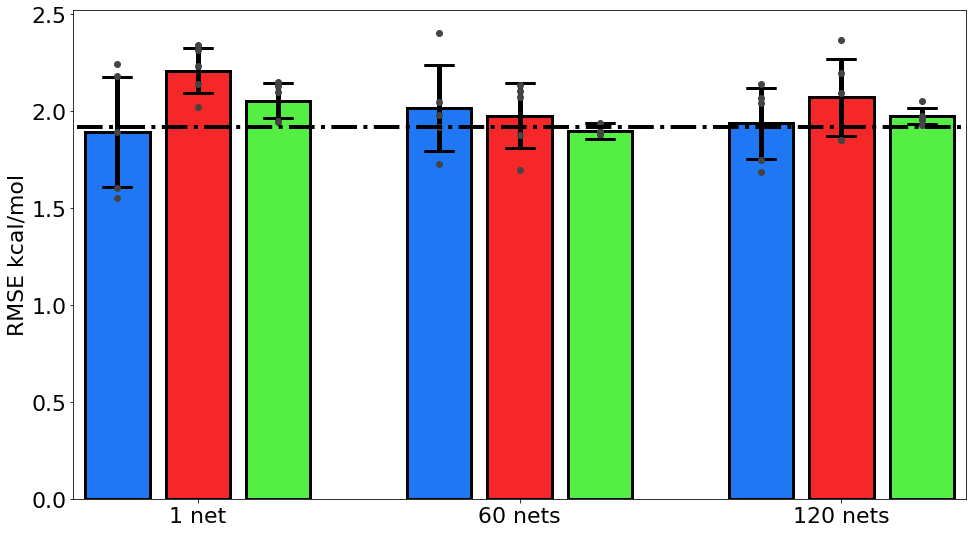

In [6]:
x_positions = [1,2,3,5,6,7,9,10,11]
Best=1.92
means=[mean_val_1p1_rmse, mean_test_1p1_rmse, mean_gen_1p1_rmse,
      mean_val_1p2_rmse, mean_test_1p2_rmse, mean_gen_1p2_rmse,
      mean_val_1p3_rmse, mean_test_1p3_rmse, mean_gen_1p3_rmse]
stds=[std_error_val_1p1_rmse, std_error_test_1p1_rmse, std_error_gen_1p1_rmse,
     std_error_val_1p2_rmse, std_error_test_1p2_rmse, std_error_gen_1p3_rmse,
     std_error_val_1p3_rmse, std_error_test_1p3_rmse, std_error_gen_1p3_rmse]

plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, color=["b","r","g"], yerr=stds, error_kw=dict(lw=5, capsize=15, capthick=3))
plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#55ee44"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
x=val_scores_1p1_rmse; plt.plot(np.ones(len(x)),x,'o', color="#444444")
x=test_scores_1p1_rmse; plt.plot(2*np.ones(len(x)),x,'o', color="#444444")
x=gen_scores_1p1_rmse; plt.plot(3*np.ones(len(x)),x,'o', color="#444444")
x=val_scores_1p2_rmse; plt.plot(5*np.ones(len(x)),x,'o', color="#444444")
x=test_scores_1p2_rmse; plt.plot(6*np.ones(len(x)),x,'o', color="#444444")
x=gen_scores_1p2_rmse; plt.plot(7*np.ones(len(x)),x,'o', color="#444444")
x=val_scores_1p3_rmse; plt.plot(9*np.ones(len(x)),x,'o', color="#444444")
x=test_scores_1p3_rmse; plt.plot(10*np.ones(len(x)),x,'o', color="#444444")
x=gen_scores_1p3_rmse; plt.plot(11*np.ones(len(x)),x,'o', color="#444444")
#x=dc_NN_MR_large_test_scores_rmse; plt.plot(4*np.ones(len(x)),x,'o', color="#444444")
plt.plot([0.5,11.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
axes.set_xlim([0.45,11.55])
plt.xticks([2,6,10],['1 net','60 nets','120 nets'])
plt.ylabel('RMSE kcal/mol')

plt.savefig("Augmentation.png")

In [91]:
print(np.array(gen_scores_1p1_rmse))
print(np.array(gen_scores_1p2_rmse))

[[1.9443712 2.0977924 2.1281023 1.9481951 2.1510773]]
[[1.9385985 1.8811473 1.8849607 1.8971605 1.8892928]]


In [93]:
from scipy.stats import ttest_1samp, ttest_ind
tscore, pvalue = ttest_ind(np.array(gen_scores_1p1_rmse)[0], np.array(gen_scores_1p2_rmse)[0], alternative='less')

print("t Statistic: ", tscore)  
print("P Value: ", pvalue)

t Statistic:  3.388076838273082
P Value:  0.9952364806832302


## Effect of features: chicken soup featurization

In [21]:
len(data[["name"]])

35

In [41]:
val_scores_2p3_rmse

[15    2.298597
 16    2.449920
 17    1.653655
 18    1.732973
 19    1.991414
 Name: val_rmse, dtype: float64]

In [42]:
test_scores_2p3_rmse

[15    2.247444
 16    1.643907
 17    2.226517
 18    1.744189
 19    1.835632
 Name: te_rmse, dtype: float64]

In [43]:
gen_scores_2p3_rmse

[15    2.507671
 16    7.578621
 17    1.909910
 18    5.888650
 19    1.852277
 Name: gen_rmse, dtype: float64]

In [44]:
print(data["name"][0])
val_scores_2p3_rmse=[data["val_rmse"][15:20]]
test_scores_2p3_rmse=[data["te_rmse"][15:20]]
gen_scores_2p3_rmse=[data["gen_rmse"][15:20]]

print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores=gen_scores_2p3_rmse, 
                                  test_scores=test_scores_2p3_rmse, 
                                  validate_scores=val_scores_2p3_rmse)
(min_gen_2p3_rmse, 
     mean_gen_2p3_rmse, 
     std_error_gen_2p3_rmse, 
     max_gen_2p3_rmse,
     min_val_2p3_rmse, 
     mean_val_2p3_rmse, 
     std_error_val_2p3_rmse, 
     max_val_2p3_rmse,
     min_test_2p3_rmse, 
     mean_test_2p3_rmse, 
     std_error_test_2p3_rmse, 
     max_test_2p3_rmse
     )=out_rmse



2021_PDBBind_core_augmented_div4_normalised.hdf5_-logKd_over_Ki_2021_03_09_NEW_YAED4head_Core_Exp1_1_1_177

		RMSE results
training: 	 1.85 <	 3.95. +/- 2.35 	< 7.58 
validation: 	 1.65 <	 2.03. +/- 0.31 	< 2.45 
testing: 	 1.64 <	 1.94. +/- 0.25 	< 2.25 


In [45]:
print(data["name"][0])
val_scores_2p4_rmse=[data["val_rmse"][20:25]]
test_scores_2p4_rmse=[data["te_rmse"][20:25]]
gen_scores_2p4_rmse=[data["gen_rmse"][20:25]]

print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores=gen_scores_2p4_rmse, 
                                  test_scores=test_scores_2p4_rmse, 
                                  validate_scores=val_scores_2p4_rmse)
(min_gen_2p4_rmse, 
     mean_gen_2p4_rmse, 
     std_error_gen_2p4_rmse, 
     max_gen_2p4_rmse,
     min_val_2p4_rmse, 
     mean_val_2p4_rmse, 
     std_error_val_2p4_rmse, 
     max_val_2p4_rmse,
     min_test_2p4_rmse, 
     mean_test_2p4_rmse, 
     std_error_test_2p4_rmse, 
     max_test_2p4_rmse
     )=out_rmse

2021_PDBBind_core_augmented_div4_normalised.hdf5_-logKd_over_Ki_2021_03_09_NEW_YAED4head_Core_Exp1_1_1_177

		RMSE results
training: 	 1.96 <	 2.17. +/- 0.248 	< 2.63 
validation: 	 1.6 <	 2.0. +/- 0.225 	< 2.25 
testing: 	 1.72 <	 2.07. +/- 0.252 	< 2.49 


In [46]:
print(data["name"][0])
val_scores_2p5_rmse=[data["val_rmse"][25:30]]
test_scores_2p5_rmse=[data["te_rmse"][25:30]]
gen_scores_2p5_rmse=[data["gen_rmse"][25:30]]

print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores=gen_scores_2p5_rmse, 
                                  test_scores=test_scores_2p5_rmse, 
                                  validate_scores=val_scores_2p5_rmse)
(min_gen_2p5_rmse, 
     mean_gen_2p5_rmse, 
     std_error_gen_2p5_rmse, 
     max_gen_2p5_rmse,
     min_val_2p5_rmse, 
     mean_val_2p5_rmse, 
     std_error_val_2p5_rmse, 
     max_val_2p5_rmse,
     min_test_2p5_rmse, 
     mean_test_2p5_rmse, 
     std_error_test_2p5_rmse, 
     max_test_2p5_rmse
     )=out_rmse

2021_PDBBind_core_augmented_div4_normalised.hdf5_-logKd_over_Ki_2021_03_09_NEW_YAED4head_Core_Exp1_1_1_177

		RMSE results
training: 	 1.94 <	 2.04. +/- 0.0772 	< 2.18 
validation: 	 1.72 <	 1.99. +/- 0.255 	< 2.43 
testing: 	 1.82 <	 2.16. +/- 0.236 	< 2.42 


In [47]:
print(data["name"][0])
val_scores_2p6_rmse=[data["val_rmse"][30:35]]
test_scores_2p6_rmse=[data["te_rmse"][30:35]]
gen_scores_2p6_rmse=[data["gen_rmse"][30:35]]

print('\n\t\tRMSE results')
out_rmse = h.nice_stats_outputter(train_scores=gen_scores_2p6_rmse, 
                                  test_scores=test_scores_2p6_rmse, 
                                  validate_scores=val_scores_2p6_rmse)
(min_gen_2p6_rmse, 
     mean_gen_2p6_rmse, 
     std_error_gen_2p6_rmse, 
     max_gen_2p6_rmse,
     min_val_2p6_rmse, 
     mean_val_2p6_rmse, 
     std_error_val_2p6_rmse, 
     max_val_2p6_rmse,
     min_test_2p6_rmse, 
     mean_test_2p6_rmse, 
     std_error_test_2p6_rmse, 
     max_test_2p6_rmse
     )=out_rmse

2021_PDBBind_core_augmented_div4_normalised.hdf5_-logKd_over_Ki_2021_03_09_NEW_YAED4head_Core_Exp1_1_1_177

		RMSE results
training: 	 1.87 <	 2.06. +/- 0.132 	< 2.28 
validation: 	 1.64 <	 1.94. +/- 0.195 	< 2.12 
testing: 	 1.64 <	 2.07. +/- 0.239 	< 2.28 


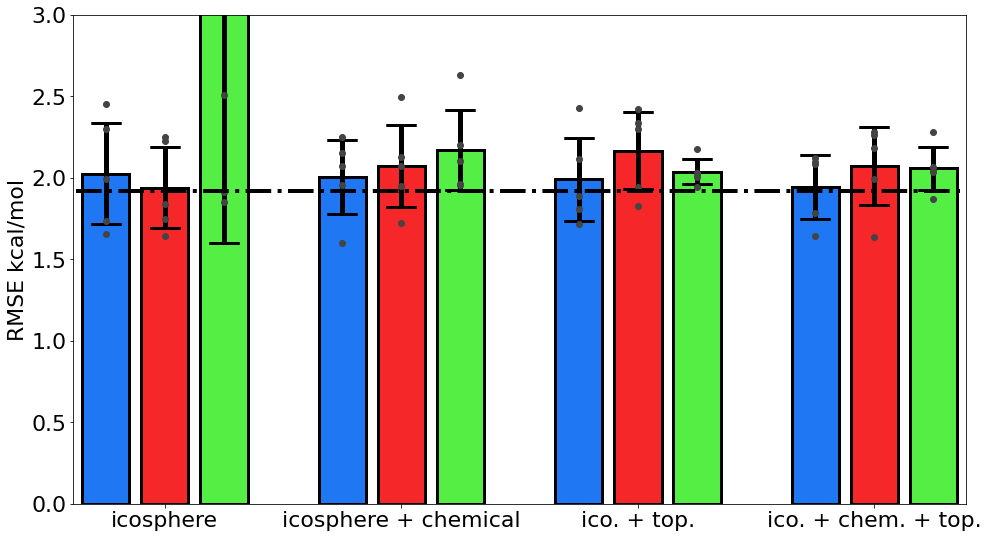

In [48]:
x_positions = [1,2,3,5,6,7,9,10,11,13,14,15]
Best=1.92
means=[mean_val_2p3_rmse, mean_test_2p3_rmse, mean_gen_2p3_rmse,
      mean_val_2p4_rmse, mean_test_2p4_rmse, mean_gen_2p4_rmse,
      mean_val_2p5_rmse, mean_test_2p5_rmse, mean_gen_2p5_rmse,
      mean_val_2p6_rmse, mean_test_2p6_rmse, mean_gen_2p6_rmse]
stds=[std_error_val_2p3_rmse, std_error_test_2p3_rmse, std_error_gen_2p3_rmse,
      std_error_val_2p4_rmse, std_error_test_2p4_rmse, std_error_gen_2p4_rmse,
      std_error_val_2p5_rmse, std_error_test_2p5_rmse, std_error_gen_2p5_rmse,
      std_error_val_2p6_rmse, std_error_test_2p6_rmse, std_error_gen_2p6_rmse]

plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, color=["b","r","g"], yerr=stds, error_kw=dict(lw=5, capsize=15, capthick=3))
plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#55ee44"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
x=val_scores_2p3_rmse; plt.plot(np.ones(len(x)),x,'o', color="#444444")
x=test_scores_2p3_rmse; plt.plot(2*np.ones(len(x)),x,'o', color="#444444")
x=gen_scores_2p3_rmse; plt.plot(3*np.ones(len(x)),x,'o', color="#444444")
x=val_scores_2p4_rmse; plt.plot(5*np.ones(len(x)),x,'o', color="#444444")
x=test_scores_2p4_rmse; plt.plot(6*np.ones(len(x)),x,'o', color="#444444")
x=gen_scores_2p4_rmse; plt.plot(7*np.ones(len(x)),x,'o', color="#444444")
x=val_scores_2p5_rmse; plt.plot(9*np.ones(len(x)),x,'o', color="#444444")
x=test_scores_2p5_rmse; plt.plot(10*np.ones(len(x)),x,'o', color="#444444")
x=gen_scores_2p5_rmse; plt.plot(11*np.ones(len(x)),x,'o', color="#444444")
x=val_scores_2p6_rmse; plt.plot(13*np.ones(len(x)),x,'o', color="#444444")
x=test_scores_2p6_rmse; plt.plot(14*np.ones(len(x)),x,'o', color="#444444")
x=gen_scores_2p6_rmse; plt.plot(15*np.ones(len(x)),x,'o', color="#444444")
#x=dc_NN_MR_large_test_scores_rmse; plt.plot(4*np.ones(len(x)),x,'o', color="#444444")
plt.plot([0.5,15.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
axes.set_ylim([0,3])
axes.set_xlim([0.45,15.55])
plt.xticks([2,6,10,14],['icosphere','icosphere + chemical','ico. + top.', 'ico. + chem. + top.'])
plt.ylabel('RMSE kcal/mol')

plt.savefig("chickensoup.png")

In [49]:
2537-1396

1141

In [50]:
1141/8

142.625

In [56]:
(184*2+107+139+44+59+272+335)/8

165.5

In [54]:
253/3

84.33333333333333

In [57]:
122*2 + 8*165+4*94+3*84

2192

In [58]:
2192/17

128.94117647058823

In [68]:
import deepchem as dc
from rdkit import Chem
from rdkit.Chem import Draw
import tensorflow as tf
tasks, datasets, transformers = dc.molnet.load_bace_regression(featurizer='GraphConv')
train_dataset, valid_dataset, test_dataset = datasets
model = dc.models.GraphConvModel(n_tasks=1, mode='regression', dropout=0.2)
model.fit(train_dataset, nb_epoch=1)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
print("Training set score:", model.evaluate(train_dataset, [metric], transformers))
print("Test set score:", model.evaluate(test_dataset, [metric], transformers))

C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\tensorflow\python\framework\indexed_slices.py:432: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


Training set score: {'pearson_r2_score': 0.004516838445182089}
Test set score: {'pearson_r2_score': 0.0013407629075658078}


In [63]:
import deepchem as dc
from rdkit import Chem
from rdkit.Chem import Draw
import tensorflow as tf
tasks, datasets, transformers = dc.molnet.load_bace_regression(featurizer='GraphConv')
train_dataset, valid_dataset, test_dataset = datasets
model = dc.models.DAGModel(n_tasks=1, mode='regression', dropout=0.2)
model.fit(train_dataset, nb_epoch=1)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
print("Training set score:", model.evaluate(train_dataset, [metric], transformers))
print("Test set score:", model.evaluate(test_dataset, [metric], transformers))

ValueError: y has more than n_class unique elements.

In [61]:
dir(model)

['__class__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_built',
 '_check_n_features',
 '_checkpoint',
 '_compute_model',
 '_create_assignment_map',
 '_create_gradient_fn',
 '_create_inputs',
 '_create_training_ops',
 '_create_value_map',
 '_ensure_built',
 '_get_param_names',
 '_get_tags',
 '_global_step',
 '_gradient_fn_for_vars',
 '_inputs_built',
 '_log_scalar_to_tensorboard',
 '_loss_fn',
 '_loss_outputs',
 '_more_tags',
 '_other_outputs',
 '_output_functions',
 '_predict',
 '_prediction_outputs',
 '_prepare_batch',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_tf_optimizer',
 '_training_ops_built',
 '_validat

In [ ]:
DeepChem version: 2.4.0
TensorFlow version: 2.3.0